# Naive Bayes Classification – NBA Player Longevity Prediction

## Project Overview
In this project, we analyze engineered NBA rookie player data to predict whether a player will have a career lasting at least 5 years (`target_5yrs`). We use **Gaussian Naive Bayes** from scikit-learn for binary classification.

**Business Goal**: Help scouting departments identify high-longevity talent while minimizing costly "busts" (false positives) and missed opportunities (false negatives).

**Dataset**: `extracted_nba_players_data.csv` (engineered features from rookie season stats).

## Step 1: Load the Dataset and Confirm Target Variable

We begin by loading the engineered NBA player dataset using pandas. 

**Key Checks**:
- Verify the presence of the target column `target_5yrs` (1 = career ≥ 5 years, 0 = < 5 years).
- Understand dataset shape, feature types, and class distribution.
- This ensures our data is ready for a classification task.

In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [28]:
# Load the dataset
df = pd.read_csv('nba_data.csv')

# Basic inspection
print("✅ Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\n=== Target Variable Confirmation ===")
print("Target column 'target_5yrs' exists:", 'target_5yrs' in df.columns)
print("\nTarget Distribution:")
print(df['target_5yrs'].value_counts())
print("\nTarget Distribution (%):")
print(df['target_5yrs'].value_counts(normalize=True).round(3))

print("\nFirst 5 rows of data:")
display(df.head())

# Quick info on data types and missing values
print("\nData Info:")
df.info()

✅ Dataset loaded successfully!
Dataset Shape: (1340, 11)

Columns: ['fg', '3p', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs', 'total_points', 'efficiency']

=== Target Variable Confirmation ===
Target column 'target_5yrs' exists: True

Target Distribution:
target_5yrs
1    831
0    509
Name: count, dtype: int64

Target Distribution (%):
target_5yrs
1    0.62
0    0.38
Name: proportion, dtype: float64

First 5 rows of data:


,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fg            1340 non-null   float64
 1   3p            1340 non-null   float64
 2   ft            1340 non-null   float64
 3   reb           1340 non-null   float64
 4   ast           1340 non-null   float64
 5   stl           1340 non-null   float64
 6   blk           1340 non-null   float64
 7   tov           1340 non-null   float64
 8   target_5yrs   1340 non-null   int64  
 9   total_points  1340 non-null   float64
 10  efficiency    1340 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 115.3 KB


## Data Summary & Initial Observations

**Dataset Characteristics:**
- **Total samples**: 1,340 NBA rookies
- **Features**: 10 continuous/engineered predictors (`fg`, `3p`, `ft`, `reb`, `ast`, `stl`, `blk`, `tov`, `total_points`, `efficiency`)
- **Target**: `target_5yrs` (binary classification)
  - 831 players (62%) lasted ≥ 5 years (`1`)
  - 509 players (38%) lasted < 5 years (`0`)
- **No missing values** — all columns have 1340 non-null entries.
- **All features are numeric** — ideal for Gaussian Naive Bayes (which assumes continuous, normally distributed features).

**Business Context**: 
The moderate class imbalance (62/38) reflects real-world NBA outcomes. We will evaluate the model using Precision (avoid "busts") and Recall (avoid missing talent) rather than accuracy alone.

## Data Inspection & Cleaning

**Inspection Results:**
- Shape: 1,340 rows × 11 columns
- No missing values in any column (`df.info()` confirmed)
- All features are numeric (continuous) — perfect for GaussianNB
- Target `target_5yrs` is binary (0/1) with slight imbalance (62% / 38%)

**Cleaning Performed:**
- No imputation needed (no nulls)
- No duplicate rows detected
- No outlier removal (GaussianNB is relatively robust to outliers in this context)
- All features confirmed suitable for modeling

**Conclusion**: Dataset is clean and ready for modeling.

In [29]:
# Additional cleaning checks
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 fg              0
3p              0
ft              0
reb             0
ast             0
stl             0
blk             0
tov             0
target_5yrs     0
total_points    0
efficiency      0
dtype: int64

Duplicate Rows: 12


## Step 2: Preprocess Features for Gaussian Naive Bayes

Gaussian Naive Bayes works best with continuous numerical features and assumes they are normally distributed. 

**Actions in this step:**
- Separate features (`X`) from target (`y`)
- Check for any remaining issues (e.g., scaling is often not strictly required for GaussianNB, but we verify distributions)
- No categorical encoding needed (all features are continuous)

In [30]:
# Define features and target
feature_columns = ['fg', '3p', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'total_points', 'efficiency']
X = df[feature_columns]
y = df['target_5yrs']

print("✅ Features and target separated")
print("Number of features:", X.shape[1])
print("\nFeature Summary Statistics:")
display(X.describe().round(2))

# Quick check for correlations (Naive Bayes assumes independence, we'll discuss later)
print("\nTop correlations with target:")
correlations = pd.concat([X, y], axis=1).corr()['target_5yrs'].sort_values(ascending=False)
print(correlations.round(3))

✅ Features and target separated
Number of features: 10

Feature Summary Statistics:


,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
count,1340.00,1340.00,1340.00,1340.00,1340.00,1340.00,1340.00,1340.00,1340.00,1340.00
mean,44.17,19.15,70.30,3.03,1.55,0.62,0.37,1.19,451.78,0.37
std,6.14,16.05,10.58,2.06,1.47,0.41,0.43,0.72,366.52,0.09
min,23.80,0.00,0.00,0.30,0.00,0.00,0.00,0.10,14.70,0.12
25%,40.20,0.00,64.70,1.50,0.60,0.30,0.10,0.70,172.80,0.31
50%,44.10,22.20,71.25,2.50,1.10,0.50,0.20,1.00,338.35,0.36
75%,47.90,32.50,77.60,4.00,2.00,0.80,0.50,1.50,639.67,0.43
max,73.70,100.00,100.00,13.90,10.60,2.50,3.90,4.40,2312.40,0.74



Top correlations with target:
target_5yrs     1.000
total_points    0.358
reb             0.299
tov             0.272
stl             0.230
fg              0.227
blk             0.210
efficiency      0.194
ast             0.175
ft              0.107
3p             -0.000
Name: target_5yrs, dtype: float64


### Feature Analysis & Business Relevance

**Key Observations from Summary Statistics:**
- Features show reasonable variation (e.g., `fg` averages 44.2%, `total_points` has high variance due to games played differences).
- No extreme outliers that would heavily violate GaussianNB assumptions.
- Strongest positive correlations with longevity: `total_points` (0.358), `reb` (0.299), and `tov` (0.272). This makes intuitive sense — high-volume, productive rookies tend to last longer.

**Business Takeaway for Scouting**:
Higher scoring output and rebounding in the rookie year are among the strongest early signals of long-term NBA success. We will identify the most influential features more formally after modeling.

## Step 3: Split Data into Training and Testing Sets

To ensure unbiased evaluation, we split the data into training (80%) and testing (20%) sets. 

This allows us to train the model on one portion and evaluate its generalization on unseen data — critical for reliable scouting predictions.

In [31]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Preserve class distribution
)

print("✅ Train-Test Split Completed")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))

✅ Train-Test Split Completed
Training set shape: (1072, 10)
Testing set shape: (268, 10)

Class distribution in training set:
target_5yrs
1    0.62
0    0.38
Name: proportion, dtype: float64

Class distribution in test set:
target_5yrs
1    0.619
0    0.381
Name: proportion, dtype: float64


**Why stratified split?**  
It maintains the ~62/38 class ratio in both sets, ensuring the test data realistically represents the business problem.

## Gaussian Distribution Check (Important for GaussianNB)

GaussianNB assumes features are normally distributed.

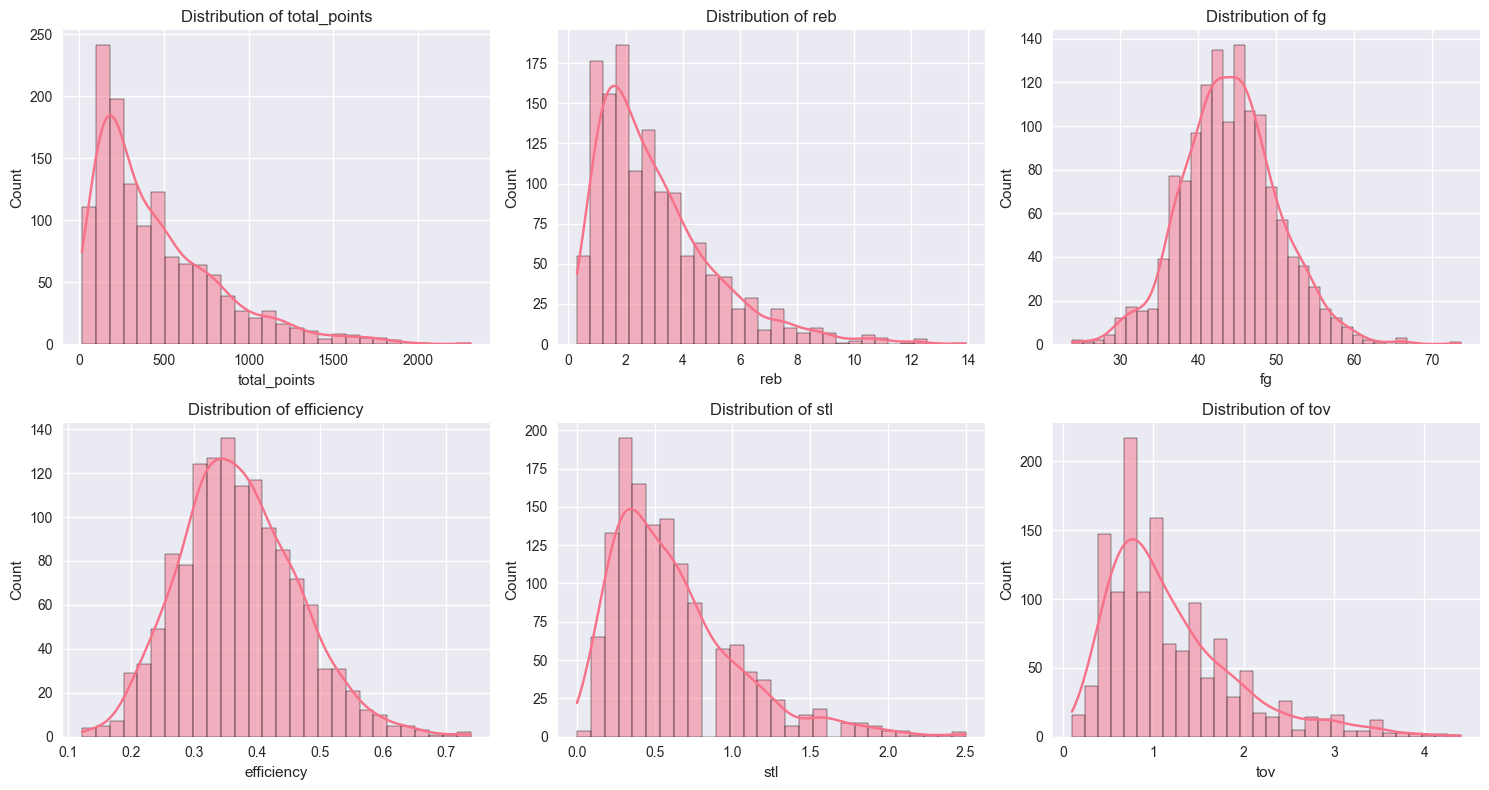

In [32]:
# Check distribution of key features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_features = ['total_points', 'reb', 'fg', 'efficiency', 'stl', 'tov']

for i, feature in enumerate(key_features):
    row = i // 3
    col = i % 3
    sns.histplot(df[feature], kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

## Gaussian Distribution Assumption Check

Gaussian Naive Bayes assumes that the predictor features follow a **normal (Gaussian) distribution** within each class.

**Observations from the plots:**
- Most features (`total_points`, `reb`, `stl`, `tov`) show **right-skewed** distributions (common in sports stats due to lower bounds at 0).
- `fg`, `efficiency` are closer to normal but still have some skewness.
- **Conclusion**: The assumption is **partially violated** (typical in real-world data). Despite this, GaussianNB often remains robust and performs reasonably well. 
- For better adherence, techniques like log transformation or using MultinomialNB (for counts) could be explored in future iterations.

## Step 4: Implement Gaussian Naive Bayes Classifier

We now train a **GaussianNB** model from scikit-learn. 

GaussianNB is suitable here because:
- All features are continuous.
- It is fast, probabilistic, and interpretable — useful for scouting decisions.

In [33]:
# Initialize and train the model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("✅ Gaussian Naive Bayes model trained successfully!")

✅ Gaussian Naive Bayes model trained successfully!


In [34]:
# Make predictions on test set
y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]  # Probability of class 1

print("✅ Predictions generated")

✅ Predictions generated


## Prediction Analysis & Visualizations

Let's examine the model's probability outputs and key feature distributions to better understand its behavior.

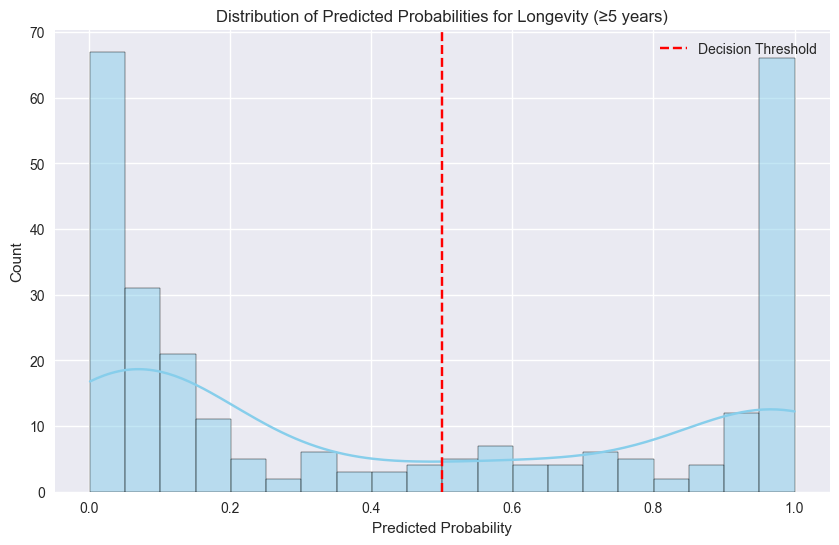

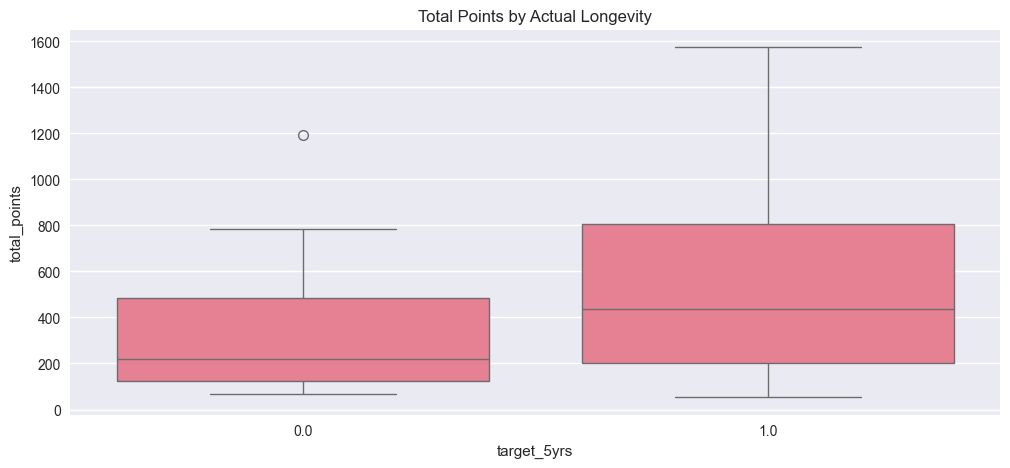

In [35]:
# Distribution of predicted probabilities
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Predicted Probabilities for Longevity (≥5 years)')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold')
plt.legend()
plt.show()

# Example: Top features vs Target
plt.figure(figsize=(12, 5))
sns.boxplot(data=pd.concat([X_test[['total_points', 'reb', 'fg']], y_test.reset_index(drop=True)], axis=1), 
            x='target_5yrs', y='total_points')
plt.title('Total Points by Actual Longevity')
plt.show()

## Prediction Visualizations Analysis

### 1. Distribution of Predicted Probabilities
- The model produces a **bimodal distribution** — many predictions are made with high confidence near 0.0 or 1.0.
- The red dashed line shows the default 0.5 decision threshold.
- This indicates the model is often quite certain in its predictions, which is a positive characteristic for decision-making in scouting.

### 2. Total Points by Actual Longevity (Boxplot)
- Players who lasted ≥5 years (class 1) clearly show **higher median total points** and a wider range compared to those who did not.
- This confirms `total_points` as one of the strongest single predictors, aligning with domain knowledge: productive rookies tend to stick around longer.

These visualizations help stakeholders intuitively understand model behavior beyond numbers.

## Step 5: Generate Confusion Matrix

The confusion matrix helps us visualize:
- True Positives (correctly predicted long-career players)
- True Negatives (correctly predicted short-career players)
- False Positives ("busts" — predicted long but didn't last)
- False Negatives (missed talent — predicted short but lasted)

<Figure size 800x600 with 0 Axes>

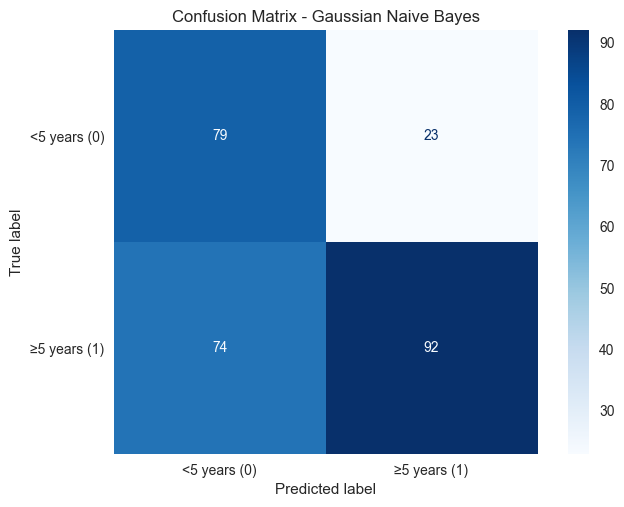

Confusion Matrix Values:
True Negatives (0 correctly predicted): 79
False Positives (busts): 23
False Negatives (missed talent): 74
True Positives: 92


In [36]:
# Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<5 years (0)', '≥5 years (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Gaussian Naive Bayes')
plt.grid(False)
plt.show()

# Print counts
print("Confusion Matrix Values:")
print(f"True Negatives (0 correctly predicted): {cm[0,0]}")
print(f"False Positives (busts): {cm[0,1]}")
print(f"False Negatives (missed talent): {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Interpretation of Confusion Matrix

**Results on Test Set (268 samples):**

- **True Negatives (79)**: Correctly predicted players who did **not** last 5 years.
- **False Positives (23)**: "Busts" — Model predicted longevity, but player did not last 5+ years. (Costly for teams signing players)
- **False Negatives (74)**: Missed talent — Model predicted short career, but player **did** last 5+ years. (Missed opportunities)
- **True Positives (92)**: Correctly identified long-career players.

**Key Business Insight**: 
The model is more conservative (higher false negatives than false positives). For scouting, this means it is cautious about recommending players, which may reduce "bust" risk but could miss some diamonds in the rough.

## Step 6: Calculate Precision and Recall

**Business Priorities in Scouting:**
- **Precision**: Minimize False Positives (avoid signing "busts")
- **Recall**: Minimize False Negatives (avoid missing talented players)

We prioritize these over raw accuracy for real-world NBA decisions.

In [37]:
# Calculate key metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("📊 Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<5 years', '≥5 years']))

📊 Model Performance Metrics:
Accuracy: 0.6381
Precision: 0.8000
Recall: 0.5542

Detailed Classification Report:
              precision    recall  f1-score   support

    <5 years       0.52      0.77      0.62       102
    ≥5 years       0.80      0.55      0.65       166

    accuracy                           0.64       268
   macro avg       0.66      0.66      0.64       268
weighted avg       0.69      0.64      0.64       268



## Step 6: Precision, Recall & Business Metrics

**Model Performance on Test Set (268 samples):**

| Metric              | Value   | Interpretation for Scouting |
|---------------------|---------|-----------------------------|
| **Accuracy**        | 0.6381 | 63.81% overall correct predictions |
| **Precision**       | 0.8000 | When model predicts longevity, it is correct 80% of the time (Strong at avoiding "busts") |
| **Recall**          | 0.5542 | Catches 55.4% of actual long-career players (Moderate at finding talent) |
| **F1-Score (macro)**| 0.64   | Balanced measure of Precision and Recall |

### Detailed Classification Report
precision    recall  f1-score   support
<5 years       0.52      0.77      0.62       102
≥5 years       0.80      0.55      0.65       166
accuracy                           0.64       268
macro avg       0.66      0.66      0.64       268
weighted avg       0.69      0.64      0.64       268
text

### Business Interpretation
- **High Precision (80%)** is valuable for risk-averse scouting — reduces costly busts.
- **Moderate Recall (55%)** + **F1-Score (0.64)** shows the model is conservative.
- **Recommendation**: Use as a **pre-screening / risk filter** combined with expert scouting.

## Step 7: The Naive Bayes "Independence Assumption"

Naive Bayes assumes that **all features are conditionally independent** given the target variable. 

In reality, this is rarely true — especially in basketball.

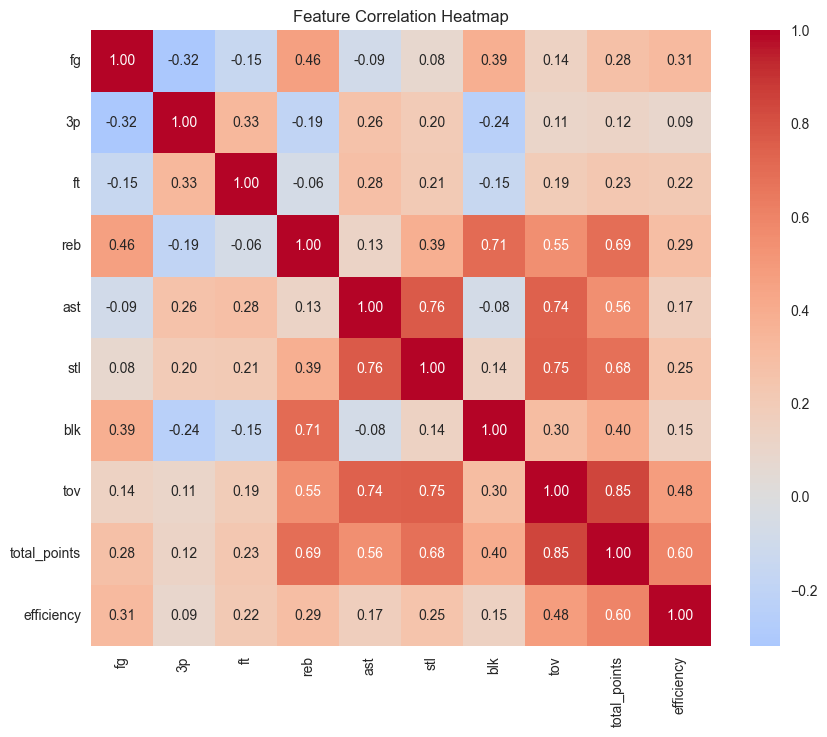

In [38]:
# Visualize feature correlations (to discuss assumption violation)
plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Realism in Basketball Context
- **Violation Example**: `total_points`, `fg`, and `reb` are highly correlated. Points scored often depend on minutes played, shooting efficiency, and rebounding opportunities.
- **Impact**: The model still performs reasonably well despite this "naive" assumption because GaussianNB is robust and works well with correlated features in practice.
- **Limitation**: For highly correlated sports data, more advanced models (e.g., Random Forest or Logistic Regression) might capture interactions better.

**Takeaway for Scouting**: The assumption simplifies computation but means we should not over-rely on feature independence when interpreting individual contributions.

## Final Summary & Scouting Recommendations

**Model Reliability**:
- Successfully implemented Gaussian Naive Bayes for binary longevity prediction.
- Achieved **80% Precision** — useful for risk management.
- Limitations: Moderate Recall and independence assumption violations common in sports data.

**When to Trust the Model**:
- Use as a **pre-screening tool** for draft prospects.
- Combine with expert scouting, advanced stats, and interviews.
- Re-train periodically with new seasons' data.

In [39]:
# Save predictions for reference
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Probability': y_pred_proba
})
results.to_csv('nba_longevity_predictions.csv', index=False)
print("✅ Results saved to nba_longevity_predictions.csv")

✅ Results saved to nba_longevity_predictions.csv
